# Week8 Ablation Study: CNN vs Decomposition + CNN


1. 复现消融实验思路；
2. 对比 A: 纯 CNN 模型；
3. 对比 B: 分解 + CNN 模型；
4. 验证分解模块是否降低了预测误差；

In [1]:
import os
import sys
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week8' else _cwd
sys.path.insert(0, os.path.join(_root, 'week5'))
sys.path.insert(0, os.path.join(_root, 'week7'))
sys.path.insert(0, os.path.join(_root, 'week8'))

from data import Electricity
from models import MultiSightCNN
from ablation import make_ablation_datasets

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'Device: {device}')

Torch version: 2.6.0+cu124
Device: cuda


## 1. 实验设置

为了让第八周的消融实验与第七周保持一致，继续采用：

- 历史窗口长度 `168 = 24 x 7`；
- 预测步长 `1`；
- 基线模型与分解模型共用同一套训练/测试样本划分。

这样可以保证对比公平，唯一变量是“是否使用分解模块”。

In [ ]:
SEQ_LEN = 168
PRED_LEN = 1
HEIGHT = 24
WIDTH = 7
PERIOD = 24
TREND_WINDOW = 25
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
RANDOM_SEED = 42 
MAX_USERS = 20 # 仅选取前20个用户，减少计算量
MAX_SAMPLES = 1000 # 每个用户设置最大滑动窗口

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

assert HEIGHT * WIDTH == SEQ_LEN

## 2. 读取 electricity 数据

这里继续复用第五周的数据加载脚本，保持代码结构一致。

In [3]:
elec = Electricity(test_ratio=0.2, max_users=MAX_USERS, max_samples_per_user=MAX_SAMPLES)
X_train, y_train, X_test, y_test = elec.get_global_slided_dataset(
    d_num=SEQ_LEN,
    h_num=PRED_LEN,
    use_global_scaler=True,
)

print(f'Users: {elec.n_users}')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

if X_train.ndim != 2 or X_test.ndim != 2 or len(X_test) == 0:
    raise ValueError(
        '当前参数下没有构造出有效的训练/测试滑窗。'
        '请增大 MAX_SAMPLES，或减小 SEQ_LEN。'
    )

Users: 20
X_train shape: (12640, 168)
y_train shape: (12640, 1)
X_test shape: (640, 168)
y_test shape: (640, 1)


## 3. 构造消融实验输入

这里同时构造两组输入：

- `baseline_*`：纯 CNN，单通道原始序列；
- `decomposed_*`：分解 + CNN，双通道趋势项 + 周期项。

In [4]:
datasets = make_ablation_datasets(
    x_train=X_train,
    y_train=y_train,
    x_test=X_test,
    y_test=y_test,
    height=HEIGHT,
    width=WIDTH,
    period=PERIOD,
    trend_window=TREND_WINDOW,
)

print(f"Baseline train X: {datasets['baseline_train_x'].shape}")
print(f"Baseline test X: {datasets['baseline_test_x'].shape}")
print(f"Decomposed train X: {datasets['decomposed_train_x'].shape}")
print(f"Decomposed test X: {datasets['decomposed_test_x'].shape}")
print(f"Train y: {datasets['train_y'].shape}")
print(f"Test y: {datasets['test_y'].shape}")

Baseline train X: (12640, 1, 24, 7)
Baseline test X: (640, 1, 24, 7)
Decomposed train X: (12640, 2, 24, 7)
Decomposed test X: (640, 2, 24, 7)
Train y: (12640, 1)
Test y: (640, 1)


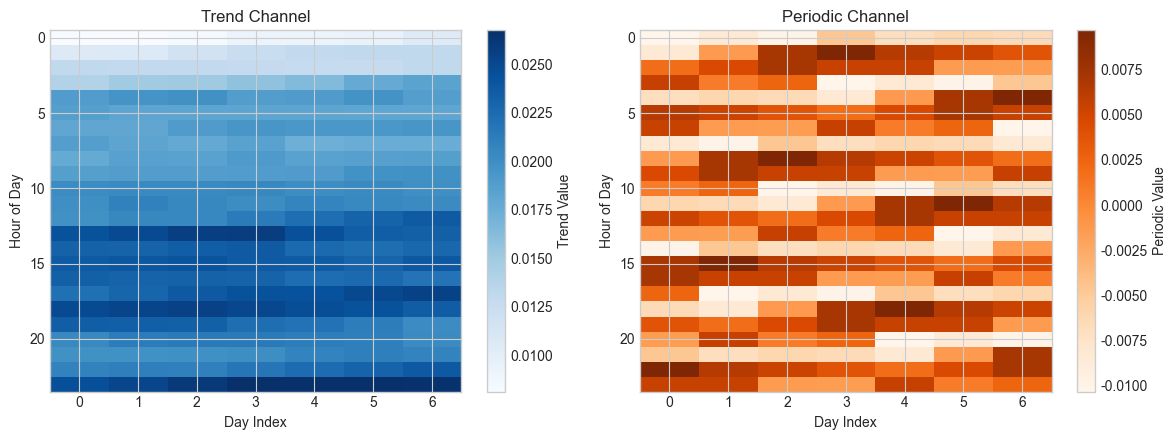

In [5]:
# 可视化一个分解样本，帮助理解双通道输入。
sample_trend = datasets['decomposed_train_x'][0, 0]
sample_periodic = datasets['decomposed_train_x'][0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im0 = axes[0].imshow(sample_trend, aspect='auto', cmap='Blues')
axes[0].set_title('Trend Channel')
axes[0].set_xlabel('Day Index')
axes[0].set_ylabel('Hour of Day')
plt.colorbar(im0, ax=axes[0], label='Trend Value')

im1 = axes[1].imshow(sample_periodic, aspect='auto', cmap='Oranges')
axes[1].set_title('Periodic Channel')
axes[1].set_xlabel('Day Index')
axes[1].set_ylabel('Hour of Day')
plt.colorbar(im1, ax=axes[1], label='Periodic Value')
plt.tight_layout()
plt.show()

趋势项：整体平滑，颜色变化缓慢；周期项：呈现明显的日模式（例如早晚高峰）。

输出图像：左侧蓝色热力图（趋势），右侧橙色热力图（周期）。验证了分解的有效性。

## 4. 构建 DataLoader

为保证对比公平，两组模型使用相同的 batch size、epoch 和优化器设置。

In [6]:
baseline_train_ds = TensorDataset(torch.from_numpy(datasets['baseline_train_x']), torch.from_numpy(datasets['train_y']))
baseline_test_ds = TensorDataset(torch.from_numpy(datasets['baseline_test_x']), torch.from_numpy(datasets['test_y']))
decomp_train_ds = TensorDataset(torch.from_numpy(datasets['decomposed_train_x']), torch.from_numpy(datasets['train_y']))
decomp_test_ds = TensorDataset(torch.from_numpy(datasets['decomposed_test_x']), torch.from_numpy(datasets['test_y']))

print(f'Baseline train samples: {len(baseline_train_ds)}')
print(f'Baseline test samples: {len(baseline_test_ds)}')
print(f'Decomp train samples: {len(decomp_train_ds)}')
print(f'Decomp test samples: {len(decomp_test_ds)}')

baseline_train_loader = DataLoader(baseline_train_ds, batch_size=BATCH_SIZE, shuffle=True)
baseline_test_loader = DataLoader(baseline_test_ds, batch_size=BATCH_SIZE, shuffle=False)
decomp_train_loader = DataLoader(decomp_train_ds, batch_size=BATCH_SIZE, shuffle=True)
decomp_test_loader = DataLoader(decomp_test_ds, batch_size=BATCH_SIZE, shuffle=False)

Baseline train samples: 12640
Baseline test samples: 640
Decomp train samples: 12640
Decomp test samples: 640


## 5. 训练与评估函数

这里复用第七周相同的训练范式，避免实验结论受到训练流程变化影响。

In [7]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for x_b, y_b in data_loader:
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            y_hat = model(x_b)
            loss = criterion(y_hat, y_b)
            total_loss += loss.item() * x_b.size(0)
            preds.append(y_hat.cpu().numpy())
            targets.append(y_b.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    mse = np.mean((preds - targets) ** 2)
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(mse)
    avg_loss = total_loss / len(data_loader.dataset)
    return avg_loss, mae, rmse


def train_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_mae': [],
        'test_rmse': [],
    }
    best_state = deepcopy(model.state_dict())
    best_rmse = float('inf')

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x_b, y_b in train_loader:
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            optimizer.zero_grad()
            y_hat = model(x_b)
            loss = criterion(y_hat, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x_b.size(0)

        train_loss = total_loss / len(train_loader.dataset)
        test_loss, test_mae, test_rmse = evaluate_model(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_mae'].append(test_mae)
        history['test_rmse'].append(test_rmse)

        if test_rmse < best_rmse:
            best_rmse = test_rmse
            best_state = deepcopy(model.state_dict())

        print(
            f'Epoch {epoch + 1:02d}/{epochs} | '
            f'train_loss={train_loss:.5f} | '
            f'test_loss={test_loss:.5f} | '
            f'test_mae={test_mae:.5f} | '
            f'test_rmse={test_rmse:.5f}'
        )

    model.load_state_dict(best_state)
    return model, history

## 6. 实验 A：纯 CNN 模型

这里采用第七周已经验证过的 Multi-sight CNN 作为基线模型，输入为单通道原始负荷矩阵。

In [8]:
print('===== Training A: Baseline CNN =====')
baseline_model = MultiSightCNN(
    in_channels=1,
    hidden_channels=16,
    kernel_sizes=(3, 5, 7),
    output_dim=PRED_LEN,
    dropout=0.1,
).to(device)

baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=baseline_train_loader,
    test_loader=baseline_test_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)

===== Training A: Baseline CNN =====
Epoch 01/10 | train_loss=0.00622 | test_loss=0.00458 | test_mae=0.04453 | test_rmse=0.06769
Epoch 02/10 | train_loss=0.00367 | test_loss=0.00149 | test_mae=0.02393 | test_rmse=0.03854
Epoch 03/10 | train_loss=0.00149 | test_loss=0.00113 | test_mae=0.02108 | test_rmse=0.03355
Epoch 04/10 | train_loss=0.00124 | test_loss=0.00103 | test_mae=0.01961 | test_rmse=0.03214
Epoch 05/10 | train_loss=0.00117 | test_loss=0.00101 | test_mae=0.01960 | test_rmse=0.03175
Epoch 06/10 | train_loss=0.00107 | test_loss=0.00099 | test_mae=0.01954 | test_rmse=0.03152
Epoch 07/10 | train_loss=0.00099 | test_loss=0.00092 | test_mae=0.01974 | test_rmse=0.03035
Epoch 08/10 | train_loss=0.00100 | test_loss=0.00089 | test_mae=0.01830 | test_rmse=0.02981
Epoch 09/10 | train_loss=0.00095 | test_loss=0.00084 | test_mae=0.01902 | test_rmse=0.02901
Epoch 10/10 | train_loss=0.00096 | test_loss=0.00086 | test_mae=0.01932 | test_rmse=0.02941


## 7. 实验 B：分解 + CNN 模型

这里保持 CNN 主体不变，只把输入替换为双通道：趋势项 + 周期项。这样可以直接考察分解模块的贡献。

In [9]:
print('===== Training B: Decomposition + CNN =====')
decomp_model = MultiSightCNN(
    in_channels=2,
    hidden_channels=16,
    kernel_sizes=(3, 5, 7),
    output_dim=PRED_LEN,
    dropout=0.1,
).to(device)

decomp_model, decomp_history = train_model(
    model=decomp_model,
    train_loader=decomp_train_loader,
    test_loader=decomp_test_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)

===== Training B: Decomposition + CNN =====
Epoch 01/10 | train_loss=0.00555 | test_loss=0.00359 | test_mae=0.03666 | test_rmse=0.05995
Epoch 02/10 | train_loss=0.00223 | test_loss=0.00089 | test_mae=0.01927 | test_rmse=0.02985
Epoch 03/10 | train_loss=0.00113 | test_loss=0.00074 | test_mae=0.01742 | test_rmse=0.02718
Epoch 04/10 | train_loss=0.00101 | test_loss=0.00088 | test_mae=0.01957 | test_rmse=0.02960
Epoch 05/10 | train_loss=0.00092 | test_loss=0.00062 | test_mae=0.01650 | test_rmse=0.02493
Epoch 06/10 | train_loss=0.00084 | test_loss=0.00057 | test_mae=0.01535 | test_rmse=0.02380
Epoch 07/10 | train_loss=0.00078 | test_loss=0.00054 | test_mae=0.01497 | test_rmse=0.02333
Epoch 08/10 | train_loss=0.00078 | test_loss=0.00059 | test_mae=0.01660 | test_rmse=0.02429
Epoch 09/10 | train_loss=0.00074 | test_loss=0.00066 | test_mae=0.01738 | test_rmse=0.02571
Epoch 10/10 | train_loss=0.00068 | test_loss=0.00049 | test_mae=0.01401 | test_rmse=0.02214


## 8. 消融实验结果对比

从训练曲线和最佳指标两个角度，判断分解模块是否有效。

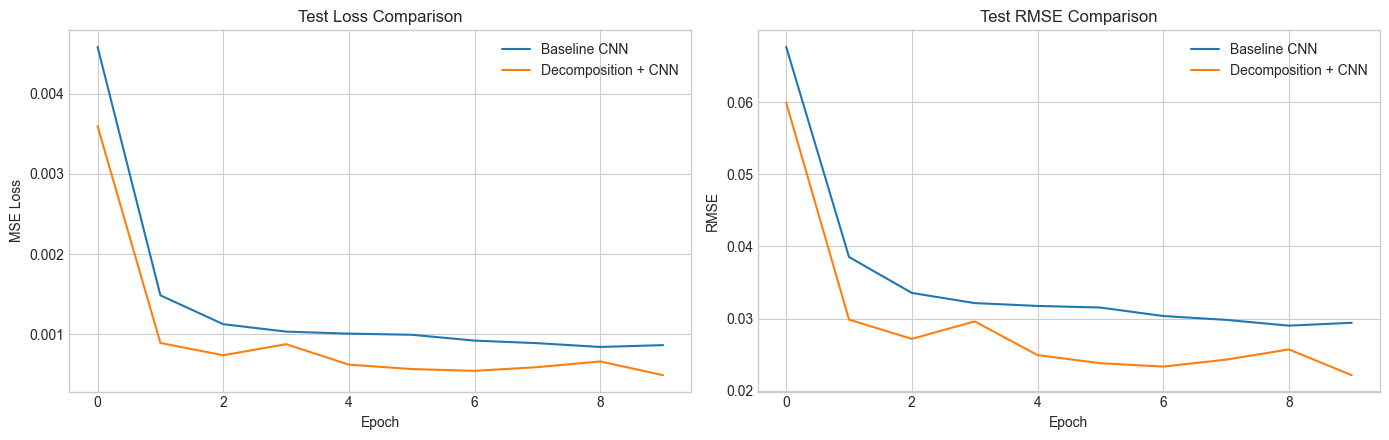

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(baseline_history['test_loss'], label='Baseline CNN')
axes[0].plot(decomp_history['test_loss'], label='Decomposition + CNN')
axes[0].set_title('Test Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(baseline_history['test_rmse'], label='Baseline CNN')
axes[1].plot(decomp_history['test_rmse'], label='Decomposition + CNN')
axes[1].set_title('Test RMSE Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
summary_df = pd.DataFrame([
    {
        'model': 'Baseline CNN',
        'best_test_mae': min(baseline_history['test_mae']),
        'best_test_rmse': min(baseline_history['test_rmse']),
        'best_test_loss': min(baseline_history['test_loss']),
    },
    {
        'model': 'Decomposition + CNN',
        'best_test_mae': min(decomp_history['test_mae']),
        'best_test_rmse': min(decomp_history['test_rmse']),
        'best_test_loss': min(decomp_history['test_loss']),
    },
]).sort_values(by='best_test_rmse').reset_index(drop=True)

summary_df

,model,best_test_mae,best_test_rmse,best_test_loss
0,Decomposition + CNN,0.014013,0.022142,0.000490
1,Baseline CNN,0.018304,0.029010,0.000842


In [12]:
baseline_best_rmse = min(baseline_history['test_rmse'])
decomp_best_rmse = min(decomp_history['test_rmse'])
rmse_improvement = baseline_best_rmse - decomp_best_rmse
rmse_improvement_ratio = rmse_improvement / baseline_best_rmse * 100

print(f'Baseline best RMSE: {baseline_best_rmse:.6f}')
print(f'Decomposition + CNN best RMSE: {decomp_best_rmse:.6f}')
print(f'Absolute RMSE improvement: {rmse_improvement:.6f}')
print(f'Relative RMSE improvement: {rmse_improvement_ratio:.2f}%')

Baseline best RMSE: 0.029010
Decomposition + CNN best RMSE: 0.022142
Absolute RMSE improvement: 0.006868
Relative RMSE improvement: 23.67%
